## Mini Projet : Comparaison de représentation classiquevs representation sémantique 

**Objectif** : Comparer des représentations textuelles classiques (TF-IDF) et sémantiques (Word2Vec, GloVe, fastText) pour la classification spam/ham en utilisant des RNNs sur les embeddings.



In [52]:
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec, KeyedVectors
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU, Dropout, Bidirectional, GlobalMaxPooling1D
import tensorflow as tf
from collections import Counter
from wordcloud import WordCloud
from gensim.models import FastText


In [3]:
tf.random.set_seed(42)
np.random.seed(42)

# Palette
PALETTE = {'ham': '#2ecc71', 'spam': '#e74c3c'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# DATA EXPLORATION

Load the Dataset

In [4]:
df = pd.read_csv("./datasets/spam.csv", sep=",", encoding="latin-1") 
print("La taille du dataset: ", df.shape)
df.head()

La taille du dataset:  (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Reperer les colonnes inutiles
print(df.columns)
# inspecter les colonnes
print("nb de valeurs nulles dans Unnamed: 2 :", df["Unnamed: 2"].isnull().sum())
print("nb de valeurs nulles dans Unnamed: 3 :", df["Unnamed: 3"].isnull().sum())
print("nb de valeurs nulles dans Unnamed: 4 :", df["Unnamed: 4"].isnull().sum())

# Supprimer les colonnes inutiles
df = df[['v1','v2']]
df.columns= ['label','message']
df.head()

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')
nb de valeurs nulles dans Unnamed: 2 : 5522
nb de valeurs nulles dans Unnamed: 3 : 5560
nb de valeurs nulles dans Unnamed: 4 : 5566


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Inspect dataset

In [6]:
print("\nNo of duplicate:")
print(df.duplicated().sum())
df = df.drop_duplicates(subset='message').reset_index(drop=True)
print("After removing duplicate:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())



No of duplicate:
403
After removing duplicate:
0

Class distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_24792\710618817.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,0].boxplot(data_by_class, labels=['HAM','SPAM'],patch_artist=True, notch=True)


Text(0.5, 0, 'Fréquence')

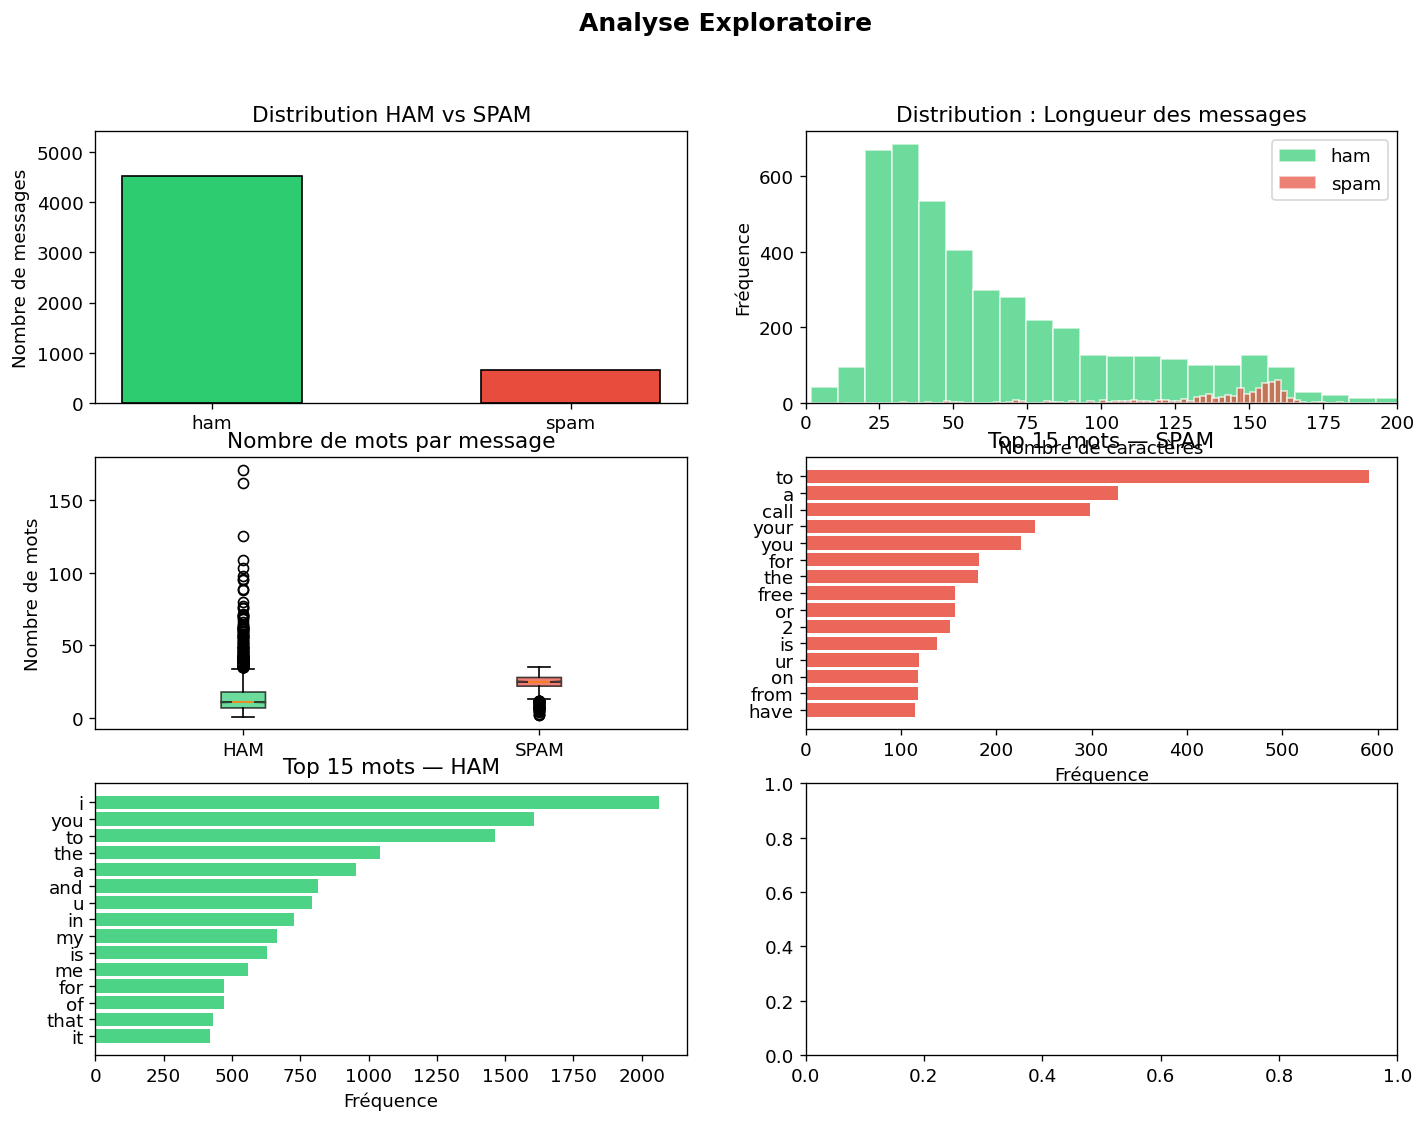

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Analyse Exploratoire", fontsize=15, fontweight='bold')

# Distribution des classes
counts = df['label'].value_counts()
axes[0,0].bar(counts.index, counts.values,
              color=[PALETTE['ham'], PALETTE['spam']], edgecolor='black', width=0.5)

axes[0,0].set_title("Distribution HAM vs SPAM")
axes[0,0].set_ylabel("Nombre de messages")
axes[0,0].set_ylim(0, counts.max()*1.2)

# Distribution de la longueur des messages
for label, color in PALETTE.items():
    subset = df[df['label']==label]['message'].str.len()
    axes[0,1].hist(subset, bins=100, alpha=0.7, color=color, label=label, edgecolor='white')
axes[0,1].set_title("Distribution : Longueur des messages")
axes[0,1].set_xlabel("Nombre de caractères")
axes[0,1].set_ylabel("Fréquence")
axes[0,1].set_xlim(0, 200)
axes[0,1].legend()

# Boxplot : nombre de mots par classe
data_by_class = [df[df['label']=='ham']['message'].str.split().str.len().values,
                 df[df['label']=='spam']['message'].str.split().str.len().values]
bp = axes[1,0].boxplot(data_by_class, labels=['HAM','SPAM'],patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], [PALETTE['ham'], PALETTE['spam']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,0].set_title("Nombre de mots par message")
axes[1,0].set_ylabel("Nombre de mots")

# Top-20 mots spam vs ham
def top_words(series, n=20):
    all_words = []
    for msg in series:
        all_words.extend(str(msg).lower().split())
    common = Counter(all_words).most_common(n)
    return pd.DataFrame(common, columns=['word','count'])

spam_top = top_words(df[df['label']=='spam']['message'])
ham_top  = top_words(df[df['label']=='ham']['message'])

axes[1,1].barh(spam_top['word'][:15][::-1], spam_top['count'][:15][::-1],
               color=PALETTE['spam'], alpha=0.85)
axes[1,1].set_title("Top 15 mots — SPAM")
axes[1,1].set_xlabel("Fréquence")

axes[2,0].barh(ham_top['word'][:15][::-1], ham_top['count'][:15][::-1],
               color=PALETTE['ham'], alpha=0.85)
axes[2,0].set_title("Top 15 mots — HAM")
axes[2,0].set_xlabel("Fréquence")

## Interprétation des résultats

Lors de l'exploration de dataset : 
- la barre 'Distribution HAM vs SPAM' montre une imbalance (HAM > SPAM). 
Le modèle peut apprendre à dire “HAM” tout le temps et obtenir une bonne accuracy artificielle, donc accuracy seule n’est pas suffisante
- **Longueur des messages** : l'histogramme montre la répartition des tailles. 
    - HAM : surtout entre 20 et 100 caractères
    - SPAM : souvent plus long (100–160)

Les spam messages sont généralement : plus longs, plus “marketing”, contiennent plus d’instructions “Call now”, “free”, “win”, “text to…”

L’analyse des mots les plus fréquents dans les messages spam met en évidence des termes caractéristiques tels que “call”, “free”, “txt”, “text” et “now”. Ces mots traduisent une intention commerciale ou incitative, souvent associée aux campagnes publicitaires ou aux tentatives de fraude. En revanche, les messages ham contiennent principalement des mots fonctionnels comme “i”, “you”, “to”, “the” et “and”, ce qui reflète un langage naturel et conversationnel.


## Nettoyege de dataset

In [8]:
import re
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

def preprocess(text):
    """
    Pipeline de nettoyage :
    1. Minuscules
    4. Suppression de la ponctuation et des chiffres
    5. Suppression des stopwords
    """
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

df['clean'] = df['message'].apply(preprocess)

print("Exemples avant / après prétraitement :")
print("─"*70)
examples = df.sample(3, random_state=1)[['label','message','clean']]
for _, row in examples.iterrows():
    print(f"[{row['label'].upper()}]")
    print(f"  AVANT  : {row['message'][:80]}")
    print(f"  APRÈS  : {row['clean'][:80]}")
    print()

# Statistiques après nettoyage
print(f"Longueur moyenne après nettoyage : {df['clean'].str.len().mean():.1f} caractères")
print(f"Messages vides après nettoyage   : {(df['clean'].str.strip()=='').sum()}")

Exemples avant / après prétraitement :
──────────────────────────────────────────────────────────────────────
[HAM]
  AVANT  : I've been barred from all B and Q stores for life!?This twat in orange dungerees
  APRÈS  : barred stores life twat orange dungerees came asked wanted decking got first pun

[HAM]
  AVANT  : Gam gone after outstanding innings.
  APRÈS  : gam gone outstanding innings

[HAM]
  AVANT  : Am okay. Will soon be over. All the best
  APRÈS  : okay soon best

Longueur moyenne après nettoyage : 50.2 caractères
Messages vides après nettoyage   : 11


In [9]:
df.head()

,label,message,clean
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts 21s...
3,ham,U dun say so early hor... U c already then say...,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


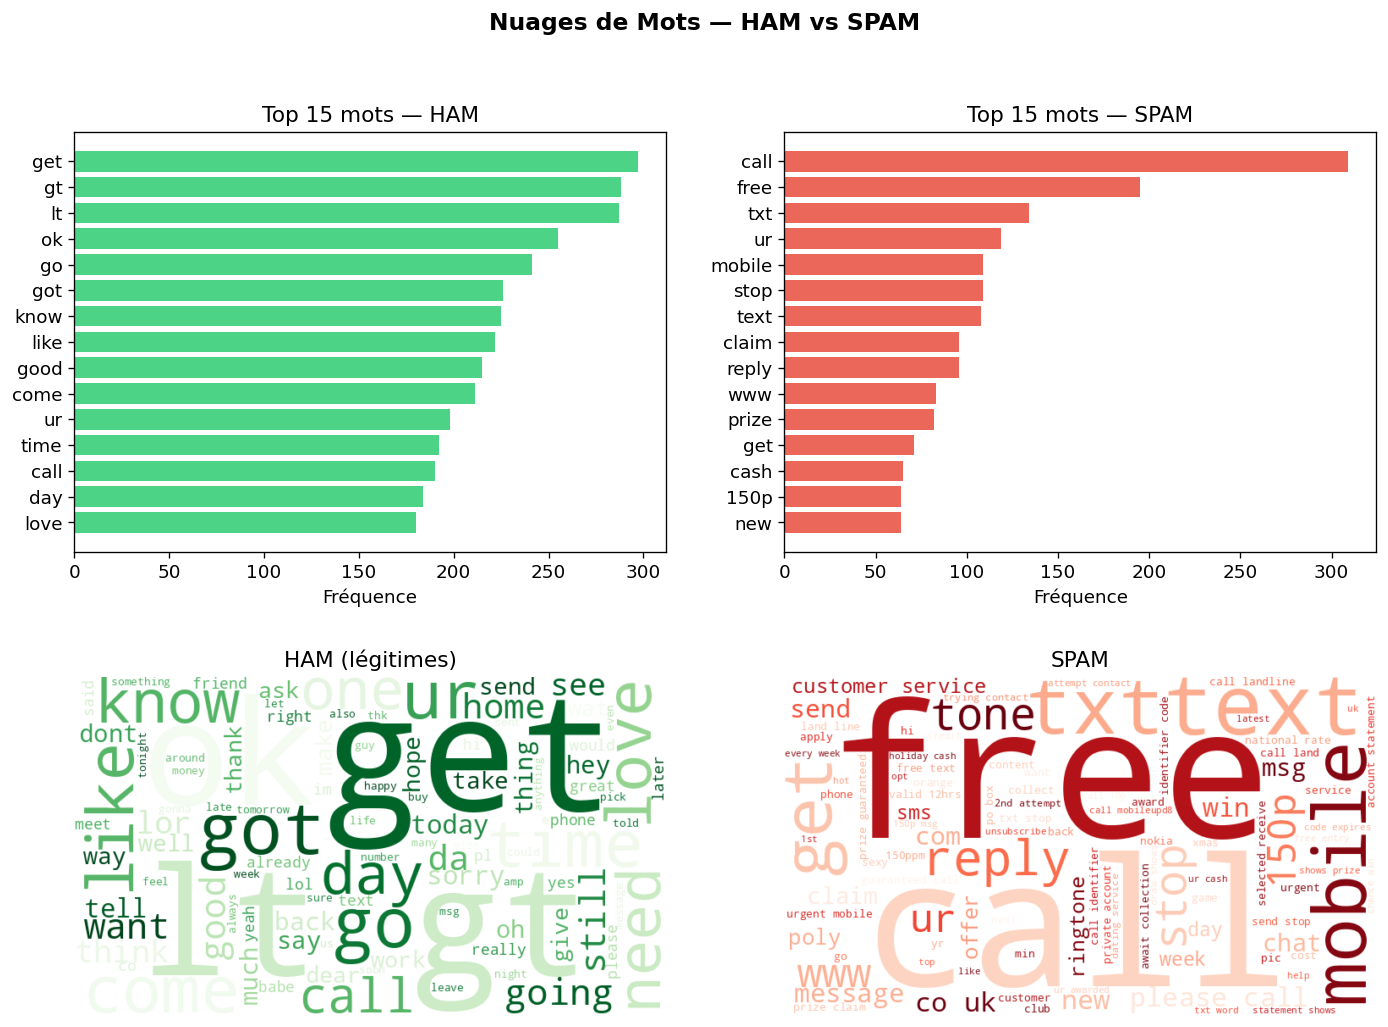

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
spam_top = top_words(df[df['label']=='spam']['clean'])
ham_top  = top_words(df[df['label']=='ham']['clean'])

axes[0,1].barh(spam_top['word'][:15][::-1], spam_top['count'][:15][::-1],
               color=PALETTE['spam'], alpha=0.85)
axes[0,1].set_title("Top 15 mots — SPAM")
axes[0,1].set_xlabel("Fréquence")

axes[0,0].barh(ham_top['word'][:15][::-1], ham_top['count'][:15][::-1],
               color=PALETTE['ham'], alpha=0.85)
axes[0,0].set_title("Top 15 mots — HAM")
axes[0,0].set_xlabel("Fréquence")

# Nuages de mots
ax3, ax4 = axes[1,0], axes[1,1]
fig.suptitle("Nuages de Mots — HAM vs SPAM", fontsize=14, fontweight='bold')

for ax, label, color in [(ax3, 'ham', 'Greens'), (ax4, 'spam', 'Reds')]:
    text = ' '.join(df[df['label']==label]['clean'].astype(str))
    wc   = WordCloud(width=700, height=400, background_color='white',
                     colormap=color, max_words=100,
                     stopwords=STOPWORDS).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{'HAM (légitimes)' if label=='ham' else 'SPAM'}", fontsize=13)
    ax.axis('off')

plt.show()

Pour les messages HAM, on observe des mots du langage quotidien comme `get, ok, go, know, like, good, love`, ce qui reflète des conversations naturelles entre personnes, avec un vocabulaire varié et sans objectif particulier de promotion. Le nuage de mots confirme cela en montrant une répartition équilibrée de termes courants.

Pour les messages SPAM, les mots les plus fréquents sont plutôt liés à la publicité ou aux arnaques, comme `call, free, claim, prize, cash, txt, mobile, reply`. On remarque aussi des termes qui incitent à agir rapidement ou à cliquer, ce qui est typique des messages commerciaux ou frauduleux. Le nuage de mots met en évidence une forte répétition de ces termes, ce qui montre un vocabulaire plus limité et orienté vers la persuasion.

Ainsi, cette analyse permet de voir clairement que les messages HAM sont naturels et variés, tandis que les SPAM utilisent un vocabulaire répétitif et orienté vers des actions ou des offres.


## RNN only

Expliation : Ce bloc montre l'approche la plus directe — entraîner un RNN simple (ou LSTM)


#### Tokenization and Padding

In [11]:
## RNN only
from tensorflow.keras.layers import Input, Embedding, Dense, LayerNormalization, MultiHeadAttention, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [12]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean'])
sequences = tokenizer.texts_to_sequences(df['clean'])

max_len = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_len)


In [13]:
padded_sequences


array([[   0,    0,    0, ...,   11, 3766,   51],
       [   0,    0,    0, ..., 1187,  307, 1570],
       [   0,    0,    0, ...,  308,  309, 3767],
       ...,
       [   0,    0,    0, ..., 8484, 1545, 8485],
       [   0,    0,    0, ...,  788,  100,    8],
       [   0,    0,    0, ..., 2205,  378,  169]],
      shape=(5169, 75), dtype=int32)

In [14]:
# Encodage des labels & Split train/test
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   

y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)
print(f"\nTrain : {len(X_train)} | Test : {len(X_test)}")
print(f"Spam dans train : {y_train.sum()} | Spam dans test : {y_test.sum()}")



Train : 4135 | Test : 1034
Spam dans train : 508 | Spam dans test : 145


In [15]:
max_words = len(tokenizer.word_index) + 1

model = Sequential([
    Embedding(input_dim=max_words, output_dim=32),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8733 - loss: 0.3980 - val_accuracy: 0.8924 - val_loss: 0.3306
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9274 - loss: 0.2215 - val_accuracy: 0.9649 - val_loss: 0.1086
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9779 - loss: 0.0758 - val_accuracy: 0.9794 - val_loss: 0.0610
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9909 - loss: 0.0325 - val_accuracy: 0.9843 - val_loss: 0.0635
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9976 - loss: 0.0128 - val_accuracy: 0.9831 - val_loss: 0.0515
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Test Accuracy: 0.9874
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       889
        spam       0.98      0.93      0.95       145

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0

## LSTM Only

In [16]:
max_words = len(tokenizer.word_index) + 1

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9039 - loss: 0.2756 - val_accuracy: 0.9649 - val_loss: 0.1246
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9788 - loss: 0.0804 - val_accuracy: 0.9746 - val_loss: 0.0724
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9912 - loss: 0.0325 - val_accuracy: 0.9867 - val_loss: 0.0376
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9973 - loss: 0.0125 - val_accuracy: 0.9843 - val_loss: 0.0498
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9982 - loss: 0.0081 - val_accuracy: 0.9855 - val_loss: 0.0426
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

Test Accuracy: 0.9836
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       889
        spam       0.96      0.92      0.94       145

    accuracy                           0.98      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.98      0.98  

## TF-IDF Vectorisation

In [17]:
# Encodage des labels & Split train/test
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   

X = df['clean'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {len(X_train)} | Test : {len(X_test)}")
print(f"Spam dans train : {y_train.sum()} | Spam dans test : {y_test.sum()}")


Train : 4135 | Test : 1034
Spam dans train : 522 | Spam dans test : 131


In [18]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf  = tfidf.transform(X_test).toarray()

print(f"Forme TF-IDF train : {X_train_tfidf.shape}")
print(f"Forme TF-IDF test  : {X_test_tfidf.shape}")
print(f"Dimension du vocabulaire : {len(tfidf.vocabulary_)}")

# Top TF-IDF features
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf_spam = X_train_tfidf[y_train==1].mean(axis=0)
top_spam_features = feature_names[np.argsort(mean_tfidf_spam)[-20:]]
print(f"\nTop features TF-IDF (SPAM) : {list(top_spam_features[::-1])}")

mean_tfidf_ham = X_train_tfidf[y_train==0].mean(axis=0)
top_ham_features = feature_names[np.argsort(mean_tfidf_ham)[-20:]]
print(f"\nTop features TF-IDF (HAM) : {list(top_ham_features[::-1])}")

Forme TF-IDF train : (4135, 10000)
Forme TF-IDF test  : (1034, 10000)
Dimension du vocabulaire : 10000

Top features TF-IDF (SPAM) : ['call', 'free', 'text', 'txt', 'mobile', 'reply', 'stop', 'claim', 'ur', 'prize', 'www', 'uk', 'new', 'cash', 'urgent', 'please call', 'com', 'please', 'send', 'service']

Top features TF-IDF (HAM) : ['ok', 'get', 'know', 'come', 'gt', 'lt', 'like', 'got', 'good', 'going', 'lt gt', 'go', 'home', 'time', 'still', 'lor', 'call', 'want', 'ur', 'da']


#### RNN sur TF-IDF


In [19]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import time

# RNN sur TF-IDF
# On reshape pour RNN : (samples, timesteps=1, features)
X_tr_tfidf_r = X_train_tfidf.reshape(-1, 1, X_train_tfidf.shape[1])
X_te_tfidf_r = X_test_tfidf.reshape(-1,  1, X_test_tfidf.shape[1])

t0 = time.time()
model = Sequential([
    SimpleRNN(64, input_shape=(1, X_train_tfidf.shape[1])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_tr_tfidf_r, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_te_tfidf_r).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/5


c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8625 - loss: 0.4945 - val_accuracy: 0.8996 - val_loss: 0.2501
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9444 - loss: 0.1539 - val_accuracy: 0.9843 - val_loss: 0.0848
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9885 - loss: 0.0453 - val_accuracy: 0.9903 - val_loss: 0.0514
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9958 - loss: 0.0184 - val_accuracy: 0.9915 - val_loss: 0.0456
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9988 - loss: 0.0100 - val_accuracy: 0.9915 - val_loss: 0.0451
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Test Accuracy=0.9758  F1=0.8996  AUC=0.9910  (5.1s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.95      0.85      0.90       131

    accuracy                           0.98      1034
   macro avg       0.96      0.92      0.94      1034
weighted avg    

####  LSTM sur TF-IDF


In [20]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import time

# LSTM sur TF-IDF
X_tr_tfidf_r = X_train_tfidf.reshape(-1, 1, X_train_tfidf.shape[1])
X_te_tfidf_r = X_test_tfidf.reshape(-1,  1, X_test_tfidf.shape[1])

t0 = time.time()
model = Sequential([
    LSTM(128, input_shape=(1, X_train_tfidf.shape[1])),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_tr_tfidf_r, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_te_tfidf_r).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))

c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8670 - loss: 0.5085 - val_accuracy: 0.8791 - val_loss: 0.2596
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9178 - loss: 0.1749 - val_accuracy: 0.9758 - val_loss: 0.1076
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9855 - loss: 0.0577 - val_accuracy: 0.9891 - val_loss: 0.0541
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9933 - loss: 0.0234 - val_accuracy: 0.9891 - val_loss: 0.0464
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9973 - loss: 0.0116 - val_accuracy: 0.9903 - val_loss: 0.0456
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Test Accuracy=0.9758  F1=0.8996  AUC=0.9908  (18.9s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.95      0.85      0.90       131

    accuracy                           0.98      1034
   macro avg       0.96      0.92      0.94      1034
weigh

## Représentation Sémantique : GloVe + RNN

In [21]:
max_len = 200

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
max_words = len(tokenizer.word_index) + 1
print("Number of unique words in dictionary =", len(tokenizer.word_index))

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

Number of unique words in dictionary = 7416


In [22]:
all_tokens = []
for text in list(X_train) + list(X_test):
    all_tokens.extend(text.split())
vocab = [w for w, c in Counter(all_tokens).items() if c >= 2]
vocab_size = len(vocab)
word2idx_glove = {w: i+1 for i, w in enumerate(vocab)}  # 0 = padding


embedding_index = {}
with open("./datasets/glove.6B/glove.6B.200d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = values[1:]
        embedding_index[word] = vector

In [23]:
# Créer la matrice d'embeddings
embedding_dim = 200
word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = np.asarray(vector, dtype='float32')

In [24]:
t0 = time.time()

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



model.fit(
    X_train_pad, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_test_pad).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9027 - loss: 0.2359 - val_accuracy: 0.9637 - val_loss: 0.0877
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9743 - loss: 0.0809 - val_accuracy: 0.9794 - val_loss: 0.0649
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9822 - loss: 0.0609 - val_accuracy: 0.9758 - val_loss: 0.0644
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9858 - loss: 0.0497 - val_accuracy: 0.9758 - val_loss: 0.0586
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9876 - loss: 0.0390 - val_accuracy: 0.9758 - val_loss: 0.0633
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

Test Accuracy=0.9691  F1=0.8750  AUC=0.9855  (12.0s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       903
        spam       0.90      0.85      0.88       131

    accuracy                           0.97      1034
   macro avg       0.94      0.92      0.93      1034
weig

In [25]:
t0 = time.time()

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



model.fit(
    X_train_pad, y_train,
    epochs=5,
    validation_split=0.2,
    shuffle=True,
    batch_size=64
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_test_pad).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.9250 - loss: 0.2130 - val_accuracy: 0.9734 - val_loss: 0.0837
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.9782 - loss: 0.0704 - val_accuracy: 0.9843 - val_loss: 0.0566
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.9831 - loss: 0.0502 - val_accuracy: 0.9831 - val_loss: 0.0569
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.9897 - loss: 0.0356 - val_accuracy: 0.9831 - val_loss: 0.0563
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - accuracy: 0.9937 - loss: 0.0237 - val_accuracy: 0.9831 - val_loss: 0.0567
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step

Test Accuracy=0.9749  F1=0.8968  AUC=0.9908  (51.7s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.93      0.86      0.90       131

    accuracy                           0.97      1034
   macro avg       0.96      0.93      0.94      1

## WORD2VEC

Expliation : Word2Vec est utilisé pour apprendre des vecteurs de mots à partir du corpus. Les étapes :
- Tokenizer le corpus d'entraînement,
- Entraîner Word2Vec (skip-gram ou CBOW) pour obtenir des vecteurs de dimension choisie,
- Construire pour chaque phrase une matrice (max_len × embed_dim) en remplaçant chaque mot par son vecteur,
- Ces matrices servent d'entrée 3D pour les modèles séquentiels (RNN/LSTM).

Remarque : Nous utilisons ici Word2Vec entraîné sur le corpus d'entraînement (ou sur le corpus augmenté après SMOTE).

In [26]:
tokenized_corpus = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,      # dimension des vecteurs
    window=5,             # fenêtre de contexte
    min_count=2,          # ignorer les mots rares
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10,
    seed=42
)

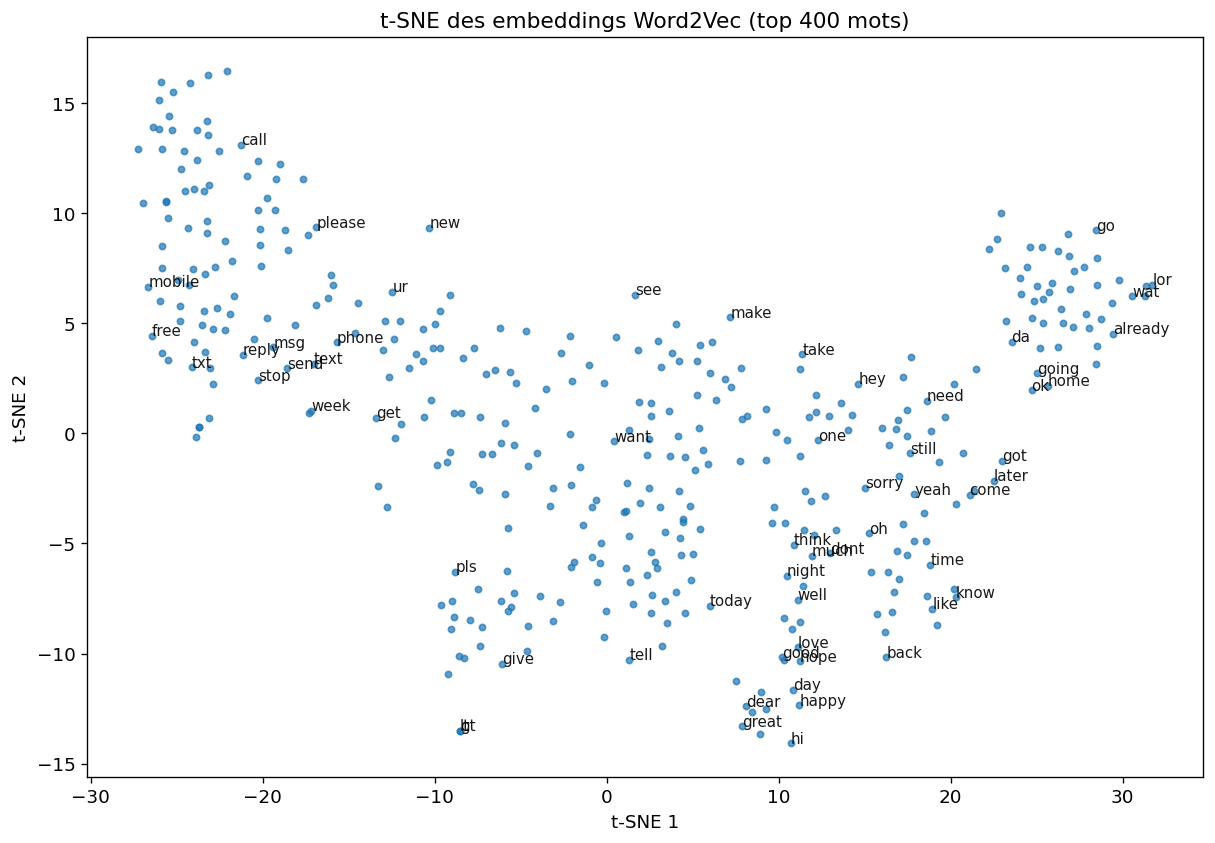

In [27]:
from sklearn.manifold import TSNE


n_words = 400   # nombre de mots projetés 
n_annot = 60    

words = w2v_model.wv.index_to_key[:n_words]                  # mots les plus fréquents
vectors = np.array([w2v_model.wv[w] for w in words])         # leurs vecteurs

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)
emb_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=14, alpha=0.7)
plt.title(f"t-SNE des embeddings Word2Vec (top {n_words} mots)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

for i in range(min(n_annot, len(words))):
    plt.annotate(words[i], (emb_2d[i, 0], emb_2d[i, 1]), fontsize=9, alpha=0.9)

plt.show()

In [28]:
print(f"Taille du vocabulaire W2V : {len(w2v_model.wv)}")
print("\nMots les plus proches de 'free' :")
if 'free' in w2v_model.wv:
    for word, sim in w2v_model.wv.most_similar('free', topn=5):
        print(f"  {word:<15} similarité={sim:.4f}")
print("\nMots les plus proches de 'call' :")
if 'call' in w2v_model.wv:
    for word, sim in w2v_model.wv.most_similar('call', topn=5):
        print(f"  {word:<15} similarité={sim:.4f}")

Taille du vocabulaire W2V : 3244

Mots les plus proches de 'free' :
  nokia           similarité=0.9610
  ringtone        similarité=0.9537
  1st             similarité=0.9510
  video           similarité=0.9489
  colour          similarité=0.9435

Mots les plus proches de 'call' :
  easy            similarité=0.9500
  line            similarité=0.9450
  08712300220     similarité=0.9359
  claim           similarité=0.9348
  10p             similarité=0.9343


In [29]:
EMBED_DIM   = 100
MAX_SEQ_LEN = 200

def text_to_w2v_matrix(texts, model, embed_dim=EMBED_DIM, max_len=MAX_SEQ_LEN):
    """
    Convertit une liste de textes en matrices 3D (n, max_len, embed_dim).
    Chaque mot est remplacé par son vecteur Word2Vec.
    """
    X = np.zeros((len(texts), max_len, embed_dim), dtype=np.float32)
    for i, text in enumerate(texts):
        tokens = text.split()[:max_len]
        for j, word in enumerate(tokens):
            if word in model.wv:
                X[i, j] = model.wv[word]
    return X

X_tr_w2v = text_to_w2v_matrix(X_train, w2v_model, EMBED_DIM, MAX_SEQ_LEN)
X_te_w2v = text_to_w2v_matrix(X_test,  w2v_model, EMBED_DIM, MAX_SEQ_LEN)
print(f"Forme W2V train : {X_tr_w2v.shape}")
print(f"Forme W2V test  : {X_te_w2v.shape}")

Forme W2V train : (4135, 200, 100)
Forme W2V test  : (1034, 200, 100)


In [30]:
t0 = time.time()

model = Sequential([
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_tr_w2v, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8767 - loss: 0.3929 - val_accuracy: 0.8791 - val_loss: 0.3702
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8730 - loss: 0.3858 - val_accuracy: 0.8791 - val_loss: 0.3695
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8724 - loss: 0.3892 - val_accuracy: 0.8791 - val_loss: 0.3694
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8724 - loss: 0.3852 - val_accuracy: 0.8791 - val_loss: 0.3689
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8730 - loss: 0.3861 - val_accuracy: 0.8803 - val_loss: 0.3667
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Test Accuracy=0.8752  F1=0.0301  AUC=0.5477  (8.7s)
              precision    recall  f1-score   support

         ham       0.88      1.00      0.93       903
        spam       1.00      0.02      0.03       131

    accuracy                           0.88      1034
   macro avg       0.94      0.51      0.48      1034
weigh

## fixing the f1 score

In [39]:
tokenized_corpus = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,      # dimension des vecteurs
    window=5,             # fenêtre de contexte
    min_count=2,          # ignorer les mots rares
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10,
    seed=42
)

EMBED_DIM   = 50
MAX_SEQ_LEN = 100

def text_to_w2v_matrix(texts, model, embed_dim=EMBED_DIM, max_len=MAX_SEQ_LEN):
    """
    Convertit une liste de textes en matrices 3D (n, max_len, embed_dim).
    Chaque mot est remplacé par son vecteur Word2Vec.
    """
    X = np.zeros((len(texts), max_len, embed_dim), dtype=np.float32)
    for i, text in enumerate(texts):
        tokens = text.split()[:max_len]
        for j, word in enumerate(tokens):
            if word in model.wv:
                X[i, j] = model.wv[word]
    return X

X_tr_w2v = text_to_w2v_matrix(X_train, w2v_model, EMBED_DIM, MAX_SEQ_LEN)
X_te_w2v = text_to_w2v_matrix(X_test,  w2v_model, EMBED_DIM, MAX_SEQ_LEN)
print(f"Forme W2V train : {X_tr_w2v.shape}")
print(f"Forme W2V test  : {X_te_w2v.shape}")

Forme W2V train : (4135, 100, 50)
Forme W2V test  : (1034, 100, 50)


In [40]:
t0 = time.time()

model = Sequential([
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_tr_w2v, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))




Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9404 - loss: 0.2369 - val_accuracy: 0.9867 - val_loss: 0.0912
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9785 - loss: 0.0866 - val_accuracy: 0.8271 - val_loss: 0.4613
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8401 - loss: 0.4237 - val_accuracy: 0.9008 - val_loss: 0.2315
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9011 - loss: 0.2248 - val_accuracy: 0.9299 - val_loss: 0.2135
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9450 - loss: 0.1574 - val_accuracy: 0.9589 - val_loss: 0.1458
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Test Accuracy=0.9594  F1=0.8359  AUC=0.9681  (4.7s)
              precision    recall  f1-score   support

         ham       0.97      0.98      0.98       903
        spam       0.86      0.82      0.84       131

    accuracy                           0.96      1034
   macro avg       0.91      0.90      0.91      1034
weight

## lstm

In [41]:
t0 = time.time()

model = Sequential([
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_tr_w2v, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9232 - loss: 0.3111 - val_accuracy: 0.9202 - val_loss: 0.1894
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8966 - loss: 0.1816 - val_accuracy: 0.9057 - val_loss: 0.1755
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.9084 - loss: 0.1730 - val_accuracy: 0.9045 - val_loss: 0.1768
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8812 - loss: 0.1974 - val_accuracy: 0.8791 - val_loss: 0.2961
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.8691 - loss: 0.2931 - val_accuracy: 0.8791 - val_loss: 0.2863
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

Test Accuracy=0.8733  F1=0.0000  AUC=0.6585  (24.1s)
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       903
        spam       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weig

c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

## Enhance F1-score using SMOTE on Embeddings

In [49]:
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Prepare your 3D W2V matrices as you did before
X_tr_w2v = text_to_w2v_matrix(X_train, w2v_model, EMBED_DIM, MAX_SEQ_LEN)
X_te_w2v = text_to_w2v_matrix(X_test,  w2v_model, EMBED_DIM, MAX_SEQ_LEN)

# 2. Reshape 3D -> 2D for SMOTE
# SMOTE needs (n_samples, MAX_SEQ_LEN * EMBED_DIM)
n_samples, seq_len, embed_dim = X_tr_w2v.shape
X_tr_flat = X_tr_w2v.reshape(n_samples, seq_len * embed_dim)

print(f"Flattened shape for SMOTE: {X_tr_flat.shape}")

# 3. Apply SMOTE
sm = SMOTE(random_state=42)
X_res_flat, y_res = sm.fit_resample(X_tr_flat, y_train)

# 4. Reshape back to 3D -> (n_resampled_samples, seq_len, embed_dim)
X_res_w2v = X_res_flat.reshape(-1, seq_len, embed_dim)

print(f"Resampled shape for LSTM: {X_res_w2v.shape}")
print(f"New class distribution: {np.bincount(y_res)}")

# 5. Build and Train LSTM
model = Sequential([
    LSTM(64, input_shape=(MAX_SEQ_LEN, EMBED_DIM)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

t0 = time.time()
model.fit(X_res_w2v, y_res, epochs=10, batch_size=64, validation_split=0.2)
elapsed = time.time() - t0

# 6. Evaluate
y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"\nSMOTE + W2V LSTM Accuracy={accuracy_score(y_test, y_pred):.4f} F1={f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Flattened shape for SMOTE: (4135, 5000)
Resampled shape for LSTM: (7226, 100, 50)
New class distribution: [3613 3613]


c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8157 - loss: 0.4191 - val_accuracy: 0.8748 - val_loss: 0.4685
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9130 - loss: 0.2983 - val_accuracy: 0.8140 - val_loss: 0.6440
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8836 - loss: 0.3464 - val_accuracy: 0.8672 - val_loss: 0.4193
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9263 - loss: 0.2669 - val_accuracy: 0.8402 - val_loss: 0.4895
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9249 - loss: 0.2712 - val_accuracy: 0.8389 - val_loss: 0.4914
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9116 - loss: 0.2915 - val_accuracy: 0.9862 - val_loss: 0.4749
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7701 - loss: 0.4248 - val_accuracy: 0.9896 - val_loss: 0.5408
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7789 - loss: 0.4158 - val_accuracy: 0.9889 - v

In [51]:
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Prepare your 3D W2V matrices as you did before
X_tr_w2v = text_to_w2v_matrix(X_train, w2v_model, EMBED_DIM, MAX_SEQ_LEN)
X_te_w2v = text_to_w2v_matrix(X_test,  w2v_model, EMBED_DIM, MAX_SEQ_LEN)

# 2. Reshape 3D -> 2D for SMOTE
# SMOTE needs (n_samples, MAX_SEQ_LEN * EMBED_DIM)
n_samples, seq_len, embed_dim = X_tr_w2v.shape
X_tr_flat = X_tr_w2v.reshape(n_samples, seq_len * embed_dim)

print(f"Flattened shape for SMOTE: {X_tr_flat.shape}")

# 3. Apply SMOTE
sm = SMOTE(random_state=42)
X_res_flat, y_res = sm.fit_resample(X_tr_flat, y_train)

# 4. Reshape back to 3D -> (n_resampled_samples, seq_len, embed_dim)
X_res_w2v = X_res_flat.reshape(-1, seq_len, embed_dim)

print(f"Resampled shape for LSTM: {X_res_w2v.shape}")
print(f"New class distribution: {np.bincount(y_res)}")

# 5. Build and Train LSTM
model = Sequential([
    LSTM(128, input_shape=(MAX_SEQ_LEN, EMBED_DIM)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

t0 = time.time()
model.fit(X_res_w2v, y_res, epochs=10, batch_size=64, validation_split=0.2)
elapsed = time.time() - t0

# 6. Evaluate
y_pred_prob = model.predict(X_te_w2v).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"\nSMOTE + W2V LSTM Accuracy={accuracy_score(y_test, y_pred):.4f} F1={f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Flattened shape for SMOTE: (4135, 5000)
Resampled shape for LSTM: (7226, 100, 50)
New class distribution: [3613 3613]
Epoch 1/10


c:\Users\user\Desktop\CI-2\s2\text mining\miniprojet\text-mining\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.7843 - loss: 0.4835 - val_accuracy: 0.7420 - val_loss: 0.5820
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.9240 - loss: 0.2657 - val_accuracy: 0.7946 - val_loss: 0.5498
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9230 - loss: 0.2670 - val_accuracy: 0.7918 - val_loss: 0.5626
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.9215 - loss: 0.2689 - val_accuracy: 0.7905 - val_loss: 0.5618
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9208 - loss: 0.2714 - val_accuracy: 0.7870 - val_loss: 0.5686
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9225 - loss: 0.2676 - val_accuracy: 0.8057 - val_loss: 0.5441
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.9240 - loss: 0.2661 - val_accuracy: 0.7988 - val_loss: 0.5740
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9215 - loss: 0.2727 - val_accuracy: 0.7981 - val_loss: 0.

## FastText


In [58]:
train_path = './tmp/ft_train.txt'
test_path  = './tmp/ft_test.txt'

def write_fasttext_file(path, texts, labels):
    with open(path, 'w', encoding='utf-8') as f:
        for msg, label in zip(texts, labels):
            lbl = '__label__spam' if label == 1 else '__label__ham'
            f.write(f"{lbl} {msg}\n")

write_fasttext_file(train_path, X_train, y_train)
write_fasttext_file(test_path, X_test, y_test)

In [61]:
import fasttext

ft_model = fasttext.train_supervised(
    input=train_path,
    dim=100,
    epoch=20,
    lr=0.1,
    wordNgrams=2,
    minCount=2,
    verbose=0
)

print("Vocab size:", len(ft_model.words))

result = ft_model.test(test_path)

print("Precision:", result[1])
print("Recall:", result[2])
print("Number of examples:", result[0])

Vocab size: 3245
Precision: 0.9806576402321083
Recall: 0.9806576402321083
Number of examples: 1034


In [62]:
import numpy as np

MAX_LEN = 50
EMBED_DIM = 100

def text_to_ft_matrix(texts, ft_model):
    X = np.zeros((len(texts), MAX_LEN, EMBED_DIM), dtype=np.float32)

    for i, text in enumerate(texts):
        tokens = str(text).split()[:MAX_LEN]

        for j, word in enumerate(tokens):
            X[i, j] = ft_model.get_word_vector(word)

    return X

X_train_ft = text_to_ft_matrix(X_train, ft_model)
X_test_ft  = text_to_ft_matrix(X_test, ft_model)

print(X_train_ft.shape)

(4135, 50, 100)


In [63]:
t0 = time.time()

model = Sequential([
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_train_ft, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_test_ft).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))




Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9169 - loss: 0.3183 - val_accuracy: 0.9045 - val_loss: 0.3149
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9311 - loss: 0.2517 - val_accuracy: 0.9504 - val_loss: 0.1925
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9574 - loss: 0.1723 - val_accuracy: 0.9504 - val_loss: 0.1898
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9577 - loss: 0.1710 - val_accuracy: 0.9516 - val_loss: 0.1859
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9411 - loss: 0.2028 - val_accuracy: 0.9021 - val_loss: 0.2365
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Test Accuracy=0.9043  F1=0.6452  AUC=0.9012  (4.0s)
              precision    recall  f1-score   support

         ham       0.95      0.94      0.94       903
        spam       0.61      0.69      0.65       131

    accuracy                           0.90      1034
   macro avg       0.78      0.81      0.79      1034
weighted a

In [65]:
n_samples, seq_len, embed_dim = X_train_ft.shape
X_tr_flat = X_train_ft.reshape(n_samples, seq_len * embed_dim)

print(f"Flattened shape for SMOTE: {X_tr_flat.shape}")

# 3. Apply SMOTE
sm = SMOTE(random_state=42)
X_res_flat, y_res = sm.fit_resample(X_tr_flat, y_train)

# 4. Reshape back to 3D -> (n_resampled_samples, seq_len, embed_dim)
X_res_ft = X_res_flat.reshape(-1, seq_len, embed_dim)

print(f"Resampled shape for LSTM: {X_res_ft.shape}")
print(f"New class distribution: {np.bincount(y_res)}")

# 5. Build and Train LSTM
t0 = time.time()

model = Sequential([
    SimpleRNN(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_res_ft, y_res,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_test_ft).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))




Flattened shape for SMOTE: (4135, 5000)
Resampled shape for LSTM: (7226, 50, 100)
New class distribution: [3613 3613]
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9554 - loss: 0.1614 - val_accuracy: 0.9564 - val_loss: 0.1249
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9780 - loss: 0.0659 - val_accuracy: 0.9869 - val_loss: 0.0561
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9825 - loss: 0.0616 - val_accuracy: 0.9585 - val_loss: 0.1589
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9789 - loss: 0.0685 - val_accuracy: 0.9869 - val_loss: 0.0524
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9844 - loss: 0.0487 - val_accuracy: 0.9862 - val_loss: 0.0502
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9865 - loss: 0.0443 - val_accuracy: 0.9426 - val_loss: 0.1415
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9884 - loss: 0.0401 - val_accuracy: 0.9882 - val_loss: 0.0401


## LSTM

In [67]:
# 5. Build and Train LSTM
t0 = time.time()

model = Sequential([
    LSTM(128),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_train_ft, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_test_ft).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.9477 - loss: 0.2056 - val_accuracy: 0.9855 - val_loss: 0.0784
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9885 - loss: 0.0504 - val_accuracy: 0.9940 - val_loss: 0.0310
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9855 - loss: 0.0462 - val_accuracy: 0.9915 - val_loss: 0.0281
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9903 - loss: 0.0329 - val_accuracy: 0.9831 - val_loss: 0.0425
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9882 - loss: 0.0406 - val_accuracy: 0.9940 - val_loss: 0.0244
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Test Accuracy=0.9758  F1=0.8954  AUC=0.9796  (33.6s)
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       903
        spam       0.99      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
wei

In [70]:
n_samples, seq_len, embed_dim = X_train_ft.shape
X_tr_flat = X_train_ft.reshape(n_samples, seq_len * embed_dim)

print(f"Flattened shape for SMOTE: {X_tr_flat.shape}")

# 3. Apply SMOTE
sm = SMOTE(random_state=42)
X_res_flat, y_res = sm.fit_resample(X_tr_flat, y_train)

# 4. Reshape back to 3D -> (n_resampled_samples, seq_len, embed_dim)
X_res_ft = X_res_flat.reshape(-1, seq_len, embed_dim)

print(f"Resampled shape for LSTM: {X_res_ft.shape}")
print(f"New class distribution: {np.bincount(y_res)}")

# 5. Build and Train LSTM
t0 = time.time()

model = Sequential([
    LSTM(128),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    X_res_ft, y_res,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

elapsed = time.time()-t0

y_pred_prob = model.predict(X_test_ft).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
elapsed = time.time() - t0
print(f"\nTest Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({elapsed:.1f}s)")
print(classification_report(y_test, y_pred, target_names=le.classes_))




Flattened shape for SMOTE: (4135, 5000)
Resampled shape for LSTM: (7226, 50, 100)
New class distribution: [3613 3613]
Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9588 - loss: 0.1466 - val_accuracy: 0.9716 - val_loss: 0.1108
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9796 - loss: 0.0567 - val_accuracy: 0.9827 - val_loss: 0.0427
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9817 - loss: 0.0546 - val_accuracy: 0.9889 - val_loss: 0.1023
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9858 - loss: 0.0638 - val_accuracy: 0.9806 - val_loss: 0.0496
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9865 - loss: 0.0469 - val_accuracy: 0.9862 - val_loss: 0.0527
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Test Accuracy=0.9778  F1=0.9105  AUC=0.9820  (19.2s)
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.93      0.89      0.91      